<a href="https://colab.research.google.com/github/RichaGaharwar/Walmart---Confidence-Interval-CLT/blob/main/Walmart_Confidence_Interval_%26_CLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **About Walmart**
---
Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

---
**Business Problem**

---

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

---
**Dataset**

---


The company collected the transactional data of customers who purchased products from the Walmart Stores during Black Friday.

The dataset has the following features:

* User_ID:	User ID
* Product_ID:	Product ID
* Gender:	Sex of User
* Age:	Age in bins
* Occupation:	Occupation(Masked)
* City_Category:	Category of the City (A,B,C)
* StayInCurrentCityYears:	Number of years stay in current city
* Marital_Status:	Marital Status
* ProductCategory:	Product Category (Masked)
* Purchase:	Purchase Amount




---

**What good looks like?**

---



* Import the dataset and do usual data analysis steps like checking the structure & characteristics of the dataset.
* Detect Null values & Outliers (using boxplot, “describe” method by checking the difference between mean and median, isnull etc.)
* do some data exploration steps like:

  * Tracking the amount spent per transaction of all the 50 million female customers, and all the 50 million male customers, calculate the average, and conclude the results.
  * Inference after computing the average female and male expenses.
  * Use the sample average to find out an interval within which the population average will lie. Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.
* Use the Central limit theorem to compute the interval. Change the sample size to observe the distribution of the mean of the expenses by female and male customers.
  * The interval that you calculated is called Confidence Interval. The width of the interval is mostly decided by the business: Typically 90%, 95%, or 99%. Play around with the width parameter and report the observations.
* conclude the results and check if the confidence intervals of average male and female spends are overlapping or not overlapping. How can Walmart leverage this conclusion to make changes or improvements?
* Perform the same activity for Married vs Unmarried and Age
  * For Age, you can try bins based on life stages: 0-17, 18-25, 26-35, 36-50, 51+ years.
* Give recommendations and action items to Walmart.



---


**Evaluation Criteria**


---



* Defining Problem Statement and Analyzing basic metrics (10 Points)
  * Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary
  * Non-Graphical Analysis: Value counts and unique attributes ​
  * Visual Analysis - Univariate & Bivariate
    * For continuous variable(s): Distplot, countplot, histogram for univariate analysis
    * For categorical variable(s): Boxplot
    * For correlation: Heatmaps, Pairplots
* Missing Value & Outlier Detection (10 Points)
* Business Insights based on Non- Graphical and Visual Analysis (10 Points)
  * Comments on the range of attributes
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plot
* Answering questions (50 Points)
  * Are women spending more money per transaction than men? Why or Why not? (10 Points)
  * Confidence intervals and distribution of the mean of the expenses by female and male customers (10 Points)
  * Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements? (10 Points)
  * Results when the same activity is performed for Married vs Unmarried (10 Points)
  * Results when the same activity is performed for Age (10 Points)
* Final Insights (10 Points) - Illustrate the insights based on exploration and CLT
  * Comments on the distribution of the variables and relationship between them
  * Comments for each univariate and bivariate plots
  * Comments on different variables when generalizing it for Population
* Recommendations (10 Points)
  * Actionable items for business. No technical jargon. No complications. Simple action items that everyone can understand

**colors**:
* Spark Yellow : '#FFC220'
* True Blue : '#0071CE'
* White : '#FFFFFF'

---

# **Exploratory Data Analysis**

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

walmart = pd.read_csv('/content/walmart.csv')

In [ ]:
walmart.shape

(550068, 10)

In [ ]:
walmart.head(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [ ]:
walmart.tail(5)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


We have 10 features and more than 550k records

In [ ]:
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


* No missing values found
* change the datatype:
  * occupation
  * product_category
  * marital status

In [ ]:
walmart['User_ID'] = walmart['User_ID'].astype(int)
walmart['Occupation'] = walmart['Occupation'].astype(object)
walmart['Product_Category'] = walmart['Product_Category'].astype(object)
walmart['Marital_Status'] = walmart['Marital_Status'].astype(object)

walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 42.0+ MB


In [ ]:
walmart['Purchase'].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


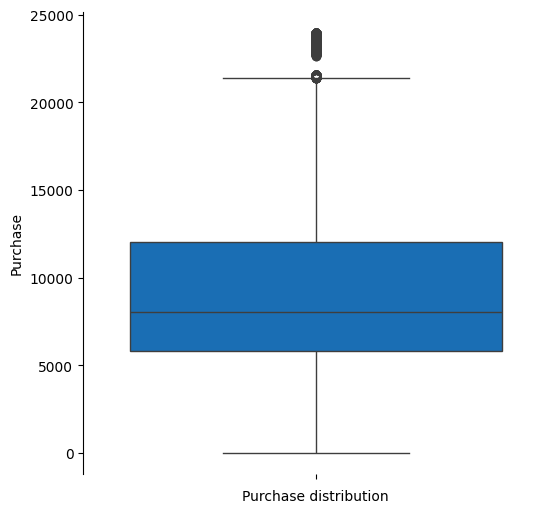

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (6, 6))
ax = plt.gca()
sns.boxplot(walmart['Purchase'], color = True_Blue)
plt.xlabel('Purchase distribution')
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

purchase amount has outliers, ie. there are people making purchases of high amounts.

Text(0.5, 1.0, 'Gender Distribution')

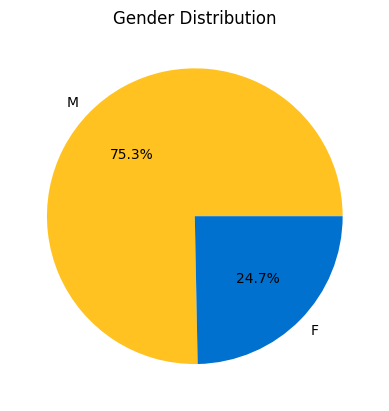

In [ ]:
plt.pie(x=walmart['Gender'].value_counts(), labels=walmart['Gender'].value_counts().index, colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('Gender Distribution')

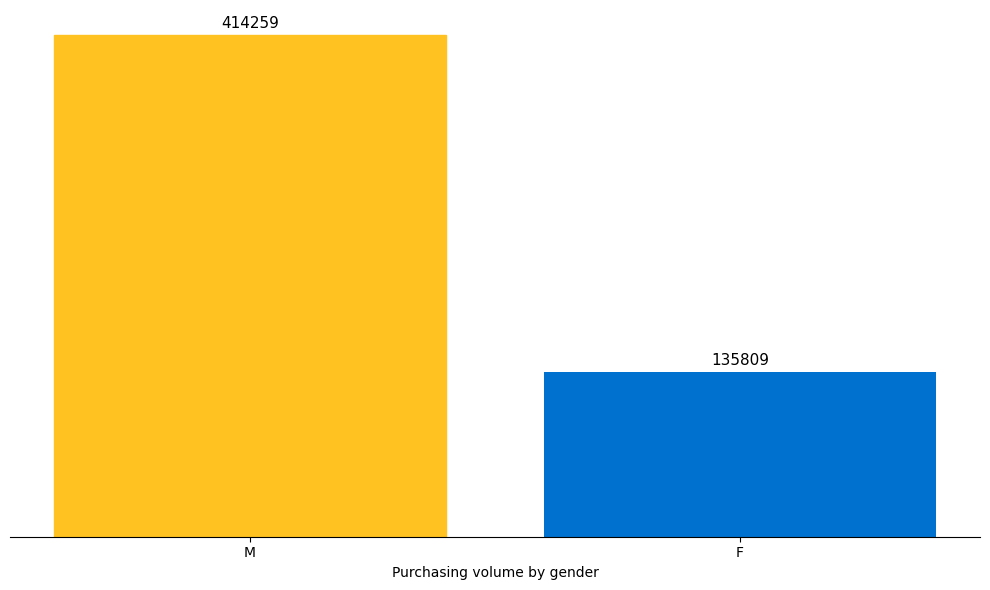

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
ax = plt.gca()
bars = plt.bar(walmart['Gender'].value_counts().index, walmart['Gender'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by gender')
plt.xticks(rotation = 0)

top_1_indices = np.argsort(walmart['Gender'].value_counts().values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

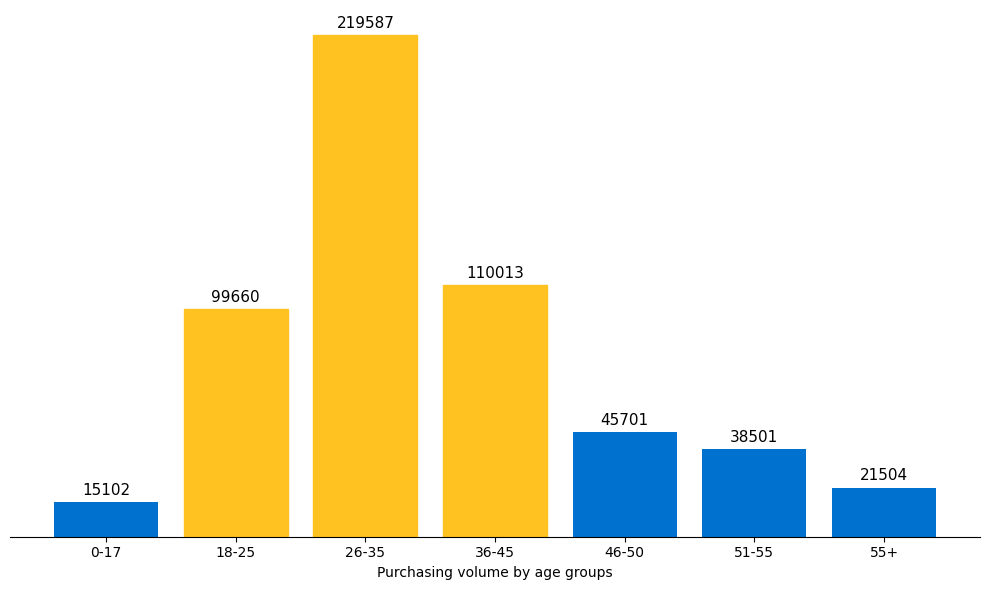

In [ ]:
age_counts = walmart['Age'].value_counts().sort_index()

Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color=True_Blue)
ax = plt.gca()
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.xlabel('Purchasing volume by age groups')
plt.ylabel('purchase_amount')
plt.xticks(rotation = 0)

top_3_indices = np.argsort(age_counts.values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
walmart['Occupation'].unique()

array([10, 16, 15, 7, 20, 9, 1, 12, 17, 0, 3, 4, 11, 8, 19, 2, 18, 5, 14,
       13, 6], dtype=object)

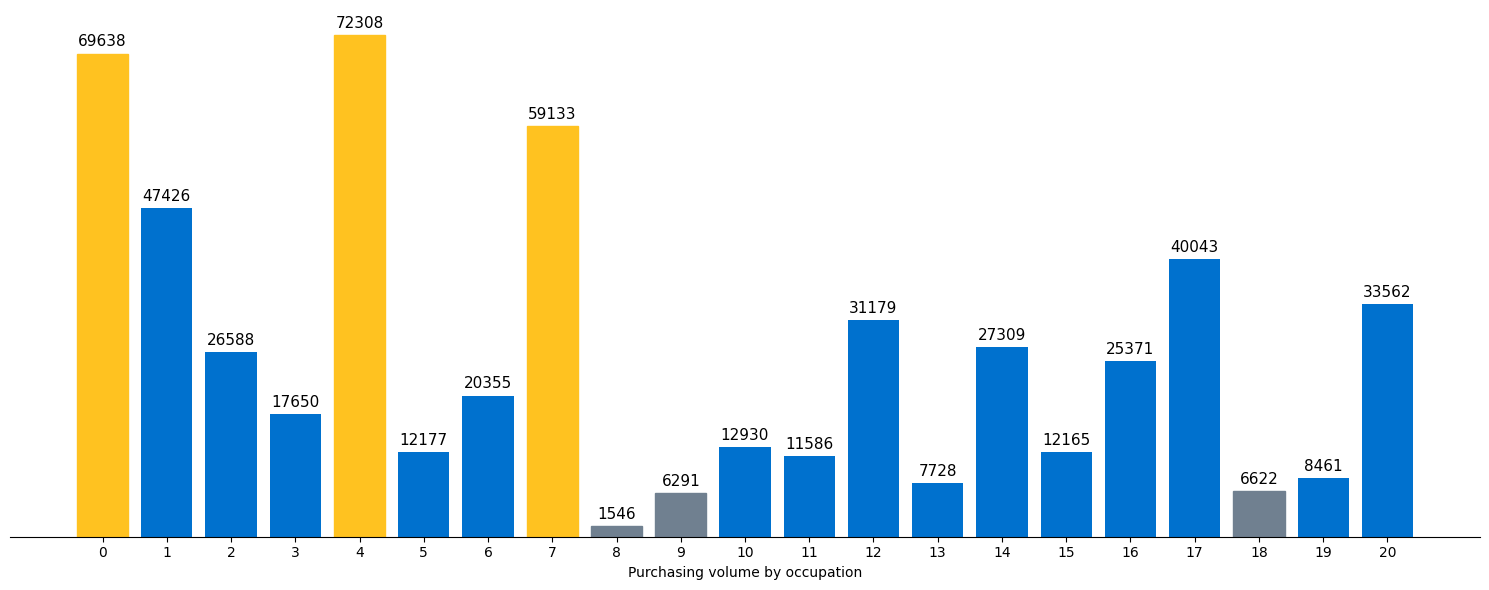

In [10]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'
Grey = '#708090'

plt.figure(figsize = (15, 6))
ax = plt.gca()
bars = plt.bar(walmart['Occupation'].value_counts().index, walmart['Occupation'].value_counts().values, color = True_Blue)
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding=3, fontsize=11)
plt.title('')
plt.xlabel('Purchasing volume by occupation')
plt.ylabel('purchase_amount')
plt.xticks(walmart['Occupation'].value_counts().index.astype(int))

top_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Occupation'].value_counts().values)[:3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Grey)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
city = walmart['City_Category'].value_counts().sort_index()

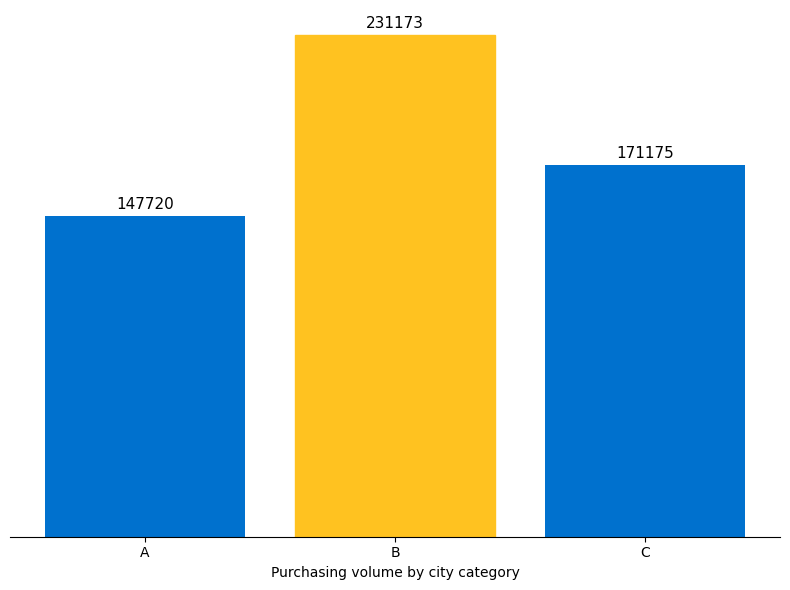

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(city.index, city.values, color = True_Blue)
plt.xlabel('Purchasing volume by city category')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
plt.xticks(rotation = 0)

top_1_indices = np.argsort(city.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
walmart['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

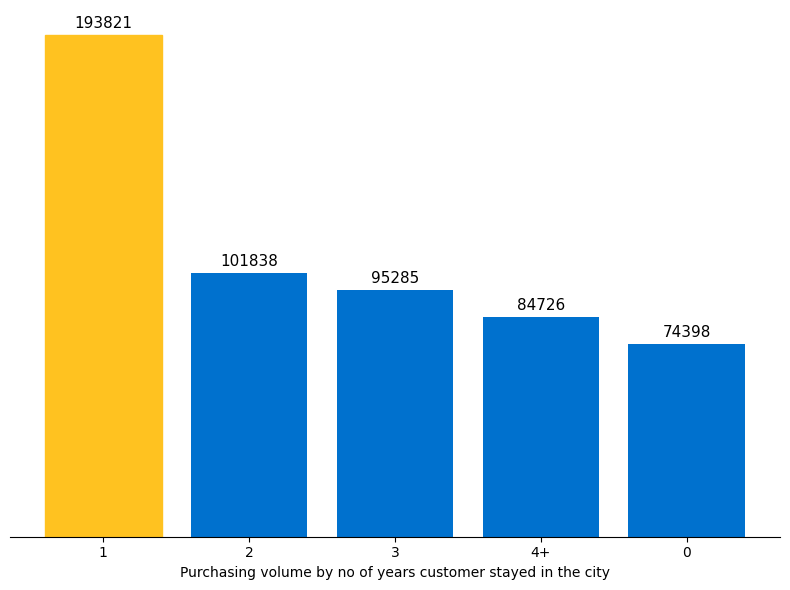

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(walmart['Stay_In_Current_City_Years'].value_counts().index, walmart['Stay_In_Current_City_Years'].value_counts().values, color = True_Blue)
plt.xlabel('Purchasing volume by no of years customer stayed in the city')
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)

top_1_indices = np.argsort(walmart['Stay_In_Current_City_Years'].value_counts().values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
marital_status = walmart['Marital_Status'].value_counts()
marital_status.index

Index([0, 1], dtype='object', name='Marital_Status')

In [ ]:
marital_status.values

array([324731, 225337])

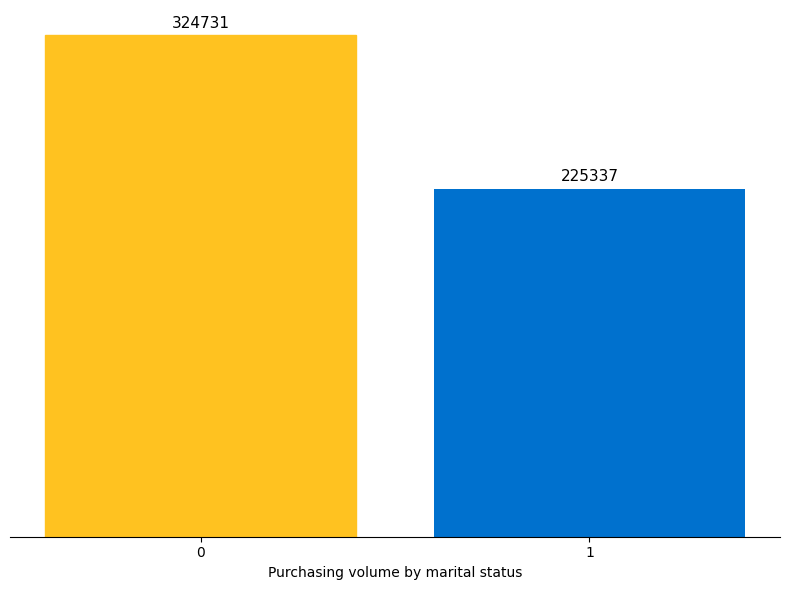

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

plt.figure(figsize = (8, 6))
ax = plt.gca()
bars = plt.bar(marital_status.index, marital_status.values, color = True_Blue)
plt.xlabel('Purchasing volume by marital status')
plt.xticks(marital_status.index.astype(int))
ax.get_yaxis().set_visible(False)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)

plt.xticks(rotation = 0)

top_1_indices = np.argsort(marital_status.values)[-1:]
for idx in top_1_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
walmart['Product_Category'].unique()

array([3, 1, 12, 8, 5, 4, 2, 6, 14, 11, 13, 15, 7, 16, 18, 10, 17, 9, 20,
       19], dtype=object)

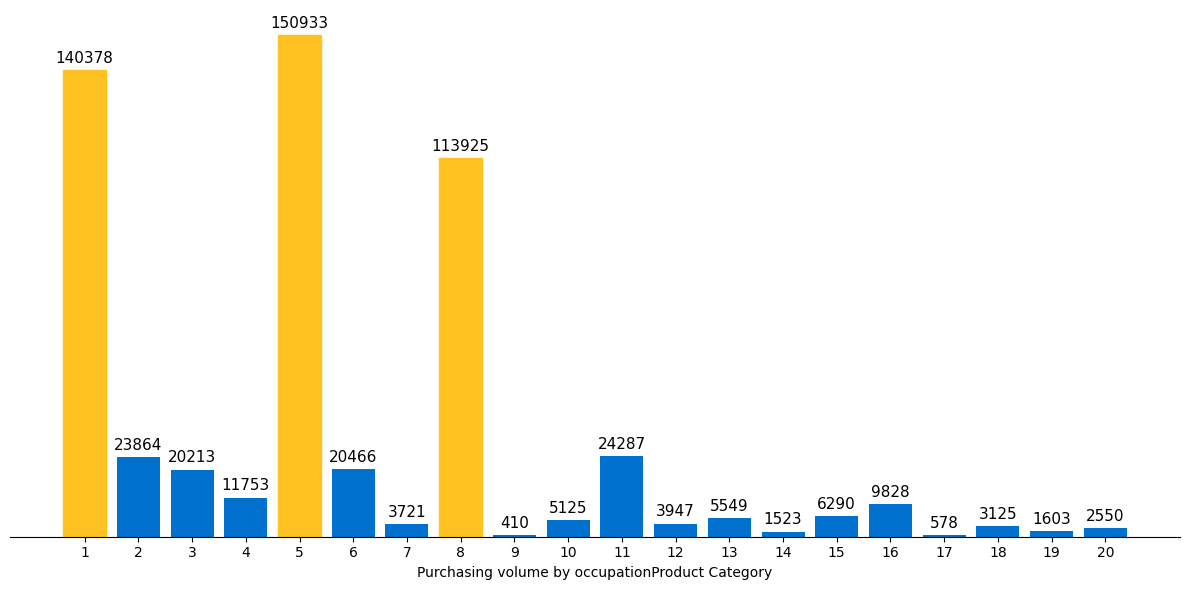

In [ ]:
Spark_Yellow = '#FFC220'
True_Blue = '#0071CE'

prod_counts = walmart['Product_Category'].value_counts()

plt.figure(figsize = (12, 6))
ax = plt.gca()
bars = plt.bar(prod_counts.index, prod_counts.values, color = True_Blue)
ax.bar_label(ax.containers[0], padding = 3, fontsize = 11)
ax.get_yaxis().set_visible(False)

plt.xticks(prod_counts.index.astype(int))

plt.xlabel('Purchasing volume by occupationProduct Category')

top_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Spark_Yellow)

bottom_3_indices = np.argsort(walmart['Product_Category'].value_counts().values)[3:]
for idx in bottom_3_indices:
    bars[idx].set_color(Spark_Yellow)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

---

# **Walmart wants to understand if the spending habits differ in:**

---

  * **male and female customers**
  * **married and single customers**
  * **different age groups**
  * **different city category**
  

---

# **Analysis based on gender**

---

```
Let's seperate the dataset based on gender
```



In [ ]:
customer_distribution_by_gender = walmart['User_ID'].groupby(walmart['Gender']).count().reset_index()
total_female_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='F']
total_male_customers = customer_distribution_by_gender[customer_distribution_by_gender['Gender']=='M']

In [ ]:
customer_distribution_by_gender

,Gender,User_ID
0,F,135809
1,M,414259


In [ ]:
unique_customers = walmart['User_ID'].groupby(walmart['Gender']).nunique().reset_index('Gender')
unique_female_customers = unique_customers[unique_customers['Gender']=='F']
unique_male_customers = unique_customers[unique_customers['Gender']=='M']


In [ ]:
unique_customers.sum()

,0
Gender,FM
User_ID,5891


In [ ]:
unique_customers

,Gender,User_ID
0,F,1666
1,M,4225


In [ ]:
avg_purchase_per_customer = walmart['User_ID'].count()/walmart['User_ID'].nunique()
avg_purchase_per_customer

np.float64(93.37429977932439)

In [ ]:
avg_purchage_female = total_female_customers['User_ID'].iloc[0] / unique_female_customers['User_ID'].iloc[0]
avg_purchage_female

np.float64(81.51800720288115)

In [ ]:
avg_purchage_male = total_male_customers['User_ID'].iloc[0] / unique_male_customers['User_ID'].iloc[0]
avg_purchage_male

np.float64(98.0494674556213)

* Total customers : 550k
  * 135809 (F)
  * 414259 (M)

* Unique customers : 5891
  * 1666 (F)
  * 4225 (M)
  
* The average number of purchases per customer : 93
  * Female : 81.52
  * Male : 98.05

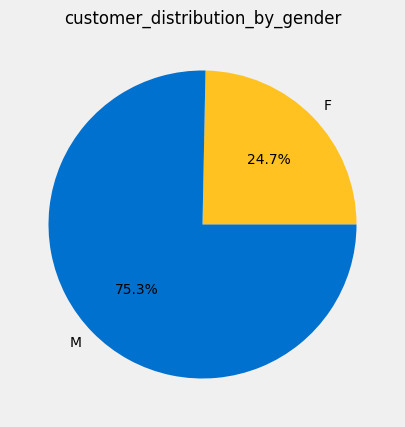

In [ ]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
plt.pie(x=customer_distribution_by_gender['User_ID'], labels=customer_distribution_by_gender['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('customer_distribution_by_gender')
plt.show()

* Females contribute to 1/4 of total transactions
* Males contribute to 3/4 of the total transactions.

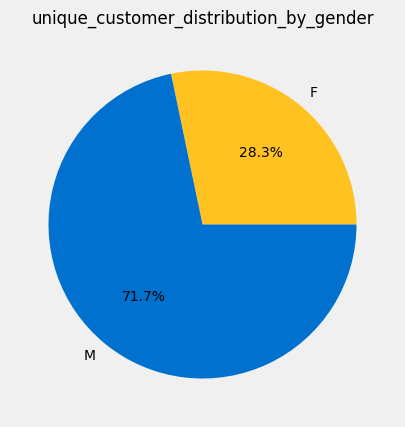

In [ ]:
plt.figure(figsize=(10,5), facecolor='#F0F0F0')
plt.pie(x=unique_customers['User_ID'], labels=unique_customers['Gender'], colors=['#FFC220', '#0071CE'], autopct='%1.1f%%')
plt.title('unique_customer_distribution_by_gender')
plt.show()

In [ ]:
walmart['Purchase'].sum()

np.int64(5095812742)

In [ ]:
walmart[walmart['Gender']=='F']['Purchase'].sum()

np.int64(1186232642)

In [ ]:
walmart[walmart['Gender']=='M']['Purchase'].sum()

np.int64(3909580100)

Proportionately, Female contributed to 1/4 of the total purchase
and male contributed to 3/4 of the total purchase

# women Dataset

In [ ]:
female_customers = walmart[walmart['Gender'] == 'F']
female_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
14,1000006,P00231342,F,51-55,9,A,1,0,5,5378
...,...,...,...,...,...,...,...,...,...,...
550061,1006029,P00372445,F,26-35,1,C,1,1,20,599
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


The amount spent per transaction, calculate the average, and conclude the results.

In [ ]:
amt_per_trans_female = female_customers['Purchase'].groupby(female_customers['User_ID']).sum()
amt_per_trans_female

,Purchase
User_ID,
1000001,334093
1000006,379930
1000010,2169510
1000011,557023
1000016,150490
...,...
1006035,956645
1006036,4116058
1006037,1119538


In [ ]:
amt_per_trans_female.sum()

np.int64(1186232642)

Use the sample average to find out an interval within which the population average will lie.

Using the sample of female customers you will calculate the interval within which the average spending of 50 million male and female customers may lie.

# Men Dataset

In [ ]:
male_customers = walmart[walmart['Gender'] == 'M']
male_customers

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
...,...,...,...,...,...,...,...,...,...,...
550057,1006023,P00370853,M,26-35,0,C,2,1,19,61
550058,1006024,P00372445,M,26-35,12,A,0,1,20,121
550060,1006026,P00371644,M,36-45,6,C,1,1,20,494
550062,1006032,P00372445,M,46-50,7,A,3,0,20,473


The amount spent per transaction, calculate the average, and conclude the results.

In [ ]:
amt_per_trans_male = male_customers['Purchase'].groupby(male_customers['User_ID']).sum()
amt_per_trans_male

,Purchase
User_ID,
1000002,810472
1000003,341635
1000004,206468
1000005,821001
1000007,234668
...,...
1006030,737361
1006032,517261
1006033,501843


In [ ]:
amt_per_trans_male.sum()

np.int64(3909580100)

# Men Vs Women

---

# **Analysis based on marital status**

---

# Single

# Married

# Single Vs Married

---

# **Analysis based on age groups**

---

# 0-17 Year olds

# 18-25 Year olds

# 26-35 Year olds

# 36-50 Year olds

# 51+

# Comparing all age groups

---

# **Analysis based on city category**

---

# City category : A

# City category : B


# City category : C

# City category : A Vs B Vs C